# Reporte de Evaluación del Modelo YOLOv8s: Señales de Tránsito de Bolivia

Este cuaderno Jupyter automatiza el análisis y visualización de la calidad de los datos del dataset, la evolución del entrenamiento y las métricas de rendimiento final (mAP, Precisión, Recall) del modelo YOLOv8s entrenado.

---

In [1]:
# 1. Importaciones necesarias
import os
import sys
import json
from pathlib import Path

# Agregar la raíz del proyecto al path de Python si el cuaderno corre desde la carpeta notebooks/
current_dir = Path(os.getcwd()).resolve()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from ultralytics import YOLO
from configs import settings

# Cambiar directorio al root del proyecto para que las rutas relativas funcionen
os.chdir(project_root)
print(f"Directorio de trabajo configurado en: {os.getcwd()}")

Directorio de trabajo configurado en: C:\Users\franz\Desktop\ProyectoTecnoII


## 1. Estadísticas del Dataset

Contaremos el número de clases, la cantidad de imágenes en el conjunto de entrenamiento y de validación.

In [2]:
train_img_dir = Path(settings.DATASET_DIR) / "train" / "images"
val_img_dir = Path(settings.DATASET_DIR) / "val" / "images"

num_classes = len(settings.CLASS_NAMES)
num_train = len(list(train_img_dir.glob("*")))
num_val = len(list(val_img_dir.glob("*")))

print("=" * 40)
print(f"Número total de clases: {num_classes}")
print(f"Imágenes de Entrenamiento (train): {num_train}")
print(f"Imágenes de Validación (val): {num_val}")
print(f"Total de imágenes en el dataset: {num_train + num_val}")
print("=" * 40)

Número total de clases: 16
Imágenes de Entrenamiento (train): 289
Imágenes de Validación (val): 52
Total de imágenes en el dataset: 341


## 2. Distribución de Clases en el Dataset

Analizaremos cuántas instancias de cada señal de tránsito existen en los conjuntos de entrenamiento y validación leyendo los archivos de anotaciones.

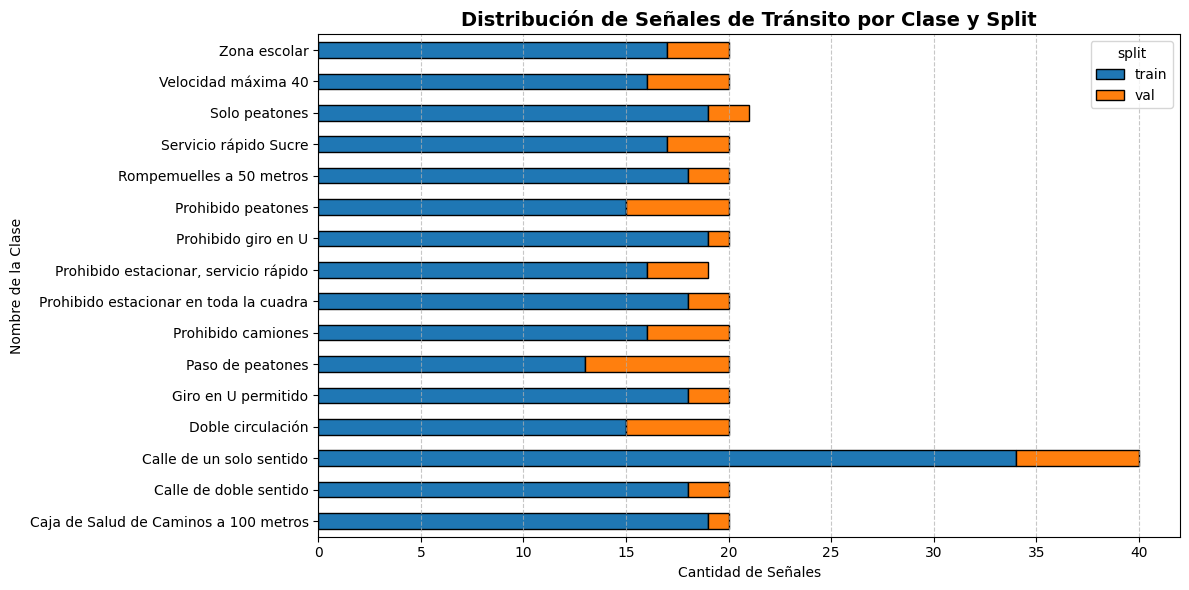

In [3]:
from utils import preprocessing

# Obtener distribución
df_dist = preprocessing.get_class_distribution(settings.DATASET_DIR)

# Mapear nombres de las clases
df_dist["nombre_clase"] = df_dist["class_id"].map(settings.CLASS_NAMES)

# Graficar la distribución
plt.figure(figsize=(12, 6))
pivot_df = df_dist.pivot(index="nombre_clase", columns="split", values="count").fillna(0)
pivot_df.plot(kind="barh", stacked=True, color=["#1f77b4", "#ff7f0e"], edgecolor="black", ax=plt.gca())
plt.title("Distribución de Señales de Tránsito por Clase y Split", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad de Señales")
plt.ylabel("Nombre de la Clase")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Curvas de Pérdidas y Evolución del Entrenamiento

Analizaremos la evolución del entrenamiento a lo largo de las 150 épocas utilizando el archivo `results.csv` autogenerado por YOLOv8.

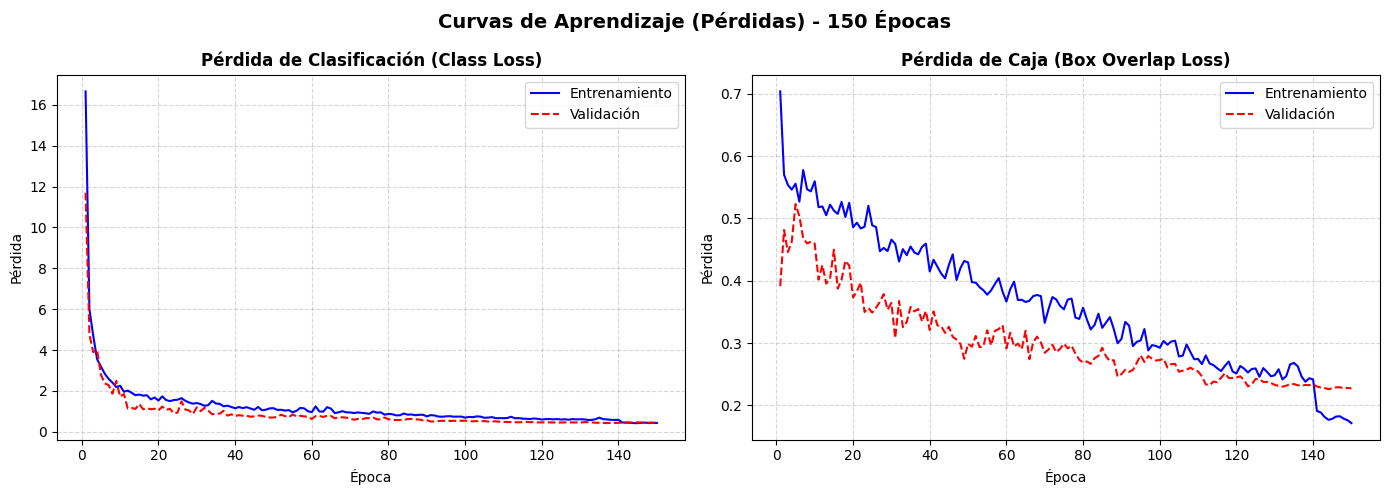

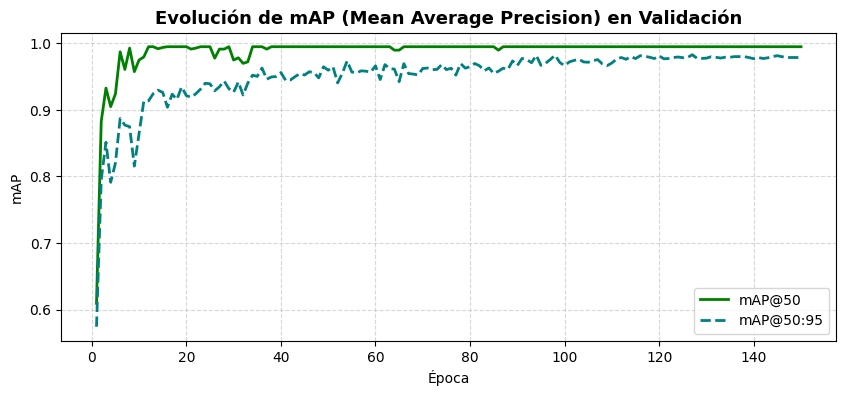

In [4]:
# Encontrar la última carpeta de entrenamiento
training_dir = Path(settings.OUTPUTS_DIR) / 'training'
run_folders = list(training_dir.glob("yolov8s_traffic_signs*"))
run_folders.sort(key=lambda p: p.stat().st_mtime, reverse=True)
latest_run = run_folders[0]

results_csv_path = latest_run / "results.csv"
df_results = pd.read_csv(results_csv_path)
# Limpiar espacios de los nombres de columnas
df_results.columns = [c.strip() for c in df_results.columns]

# Graficar Pérdidas (Pérdida de clasificación y Pérdida de regresión/caja)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clasificación (Cls Loss)
axes[0].plot(df_results["epoch"], df_results["train/cls_loss"], label="Entrenamiento", color="blue")
axes[0].plot(df_results["epoch"], df_results["val/cls_loss"], label="Validación", color="red", linestyle="--")
axes[0].set_title("Pérdida de Clasificación (Class Loss)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Pérdida")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Regresión de Cajas (Box Loss)
axes[1].plot(df_results["epoch"], df_results["train/box_loss"], label="Entrenamiento", color="blue")
axes[1].plot(df_results["epoch"], df_results["val/box_loss"], label="Validación", color="red", linestyle="--")
axes[1].set_title("Pérdida de Caja (Box Overlap Loss)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Curvas de Aprendizaje (Pérdidas) - 150 Épocas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Graficar Evolución de Métricas de Precisión (mAP50)
plt.figure(figsize=(10, 4))
plt.plot(df_results["epoch"], df_results["metrics/mAP50(B)"], color="green", linewidth=2, label="mAP@50")
plt.plot(df_results["epoch"], df_results["metrics/mAP50-95(B)"], color="teal", linewidth=2, linestyle="--", label="mAP@50:95")
plt.title("Evolución de mAP (Mean Average Precision) en Validación", fontsize=13, fontweight="bold")
plt.xlabel("Época")
plt.ylabel("mAP")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 4. Gráficos de Evaluación Autogenerados por YOLOv8

Mostraremos la matriz de confusión normalizada y el tablero general de resultados autogenerados al terminar el entrenamiento.

--- MATRIZ DE CONFUSIÓN NORMALIZADA ---


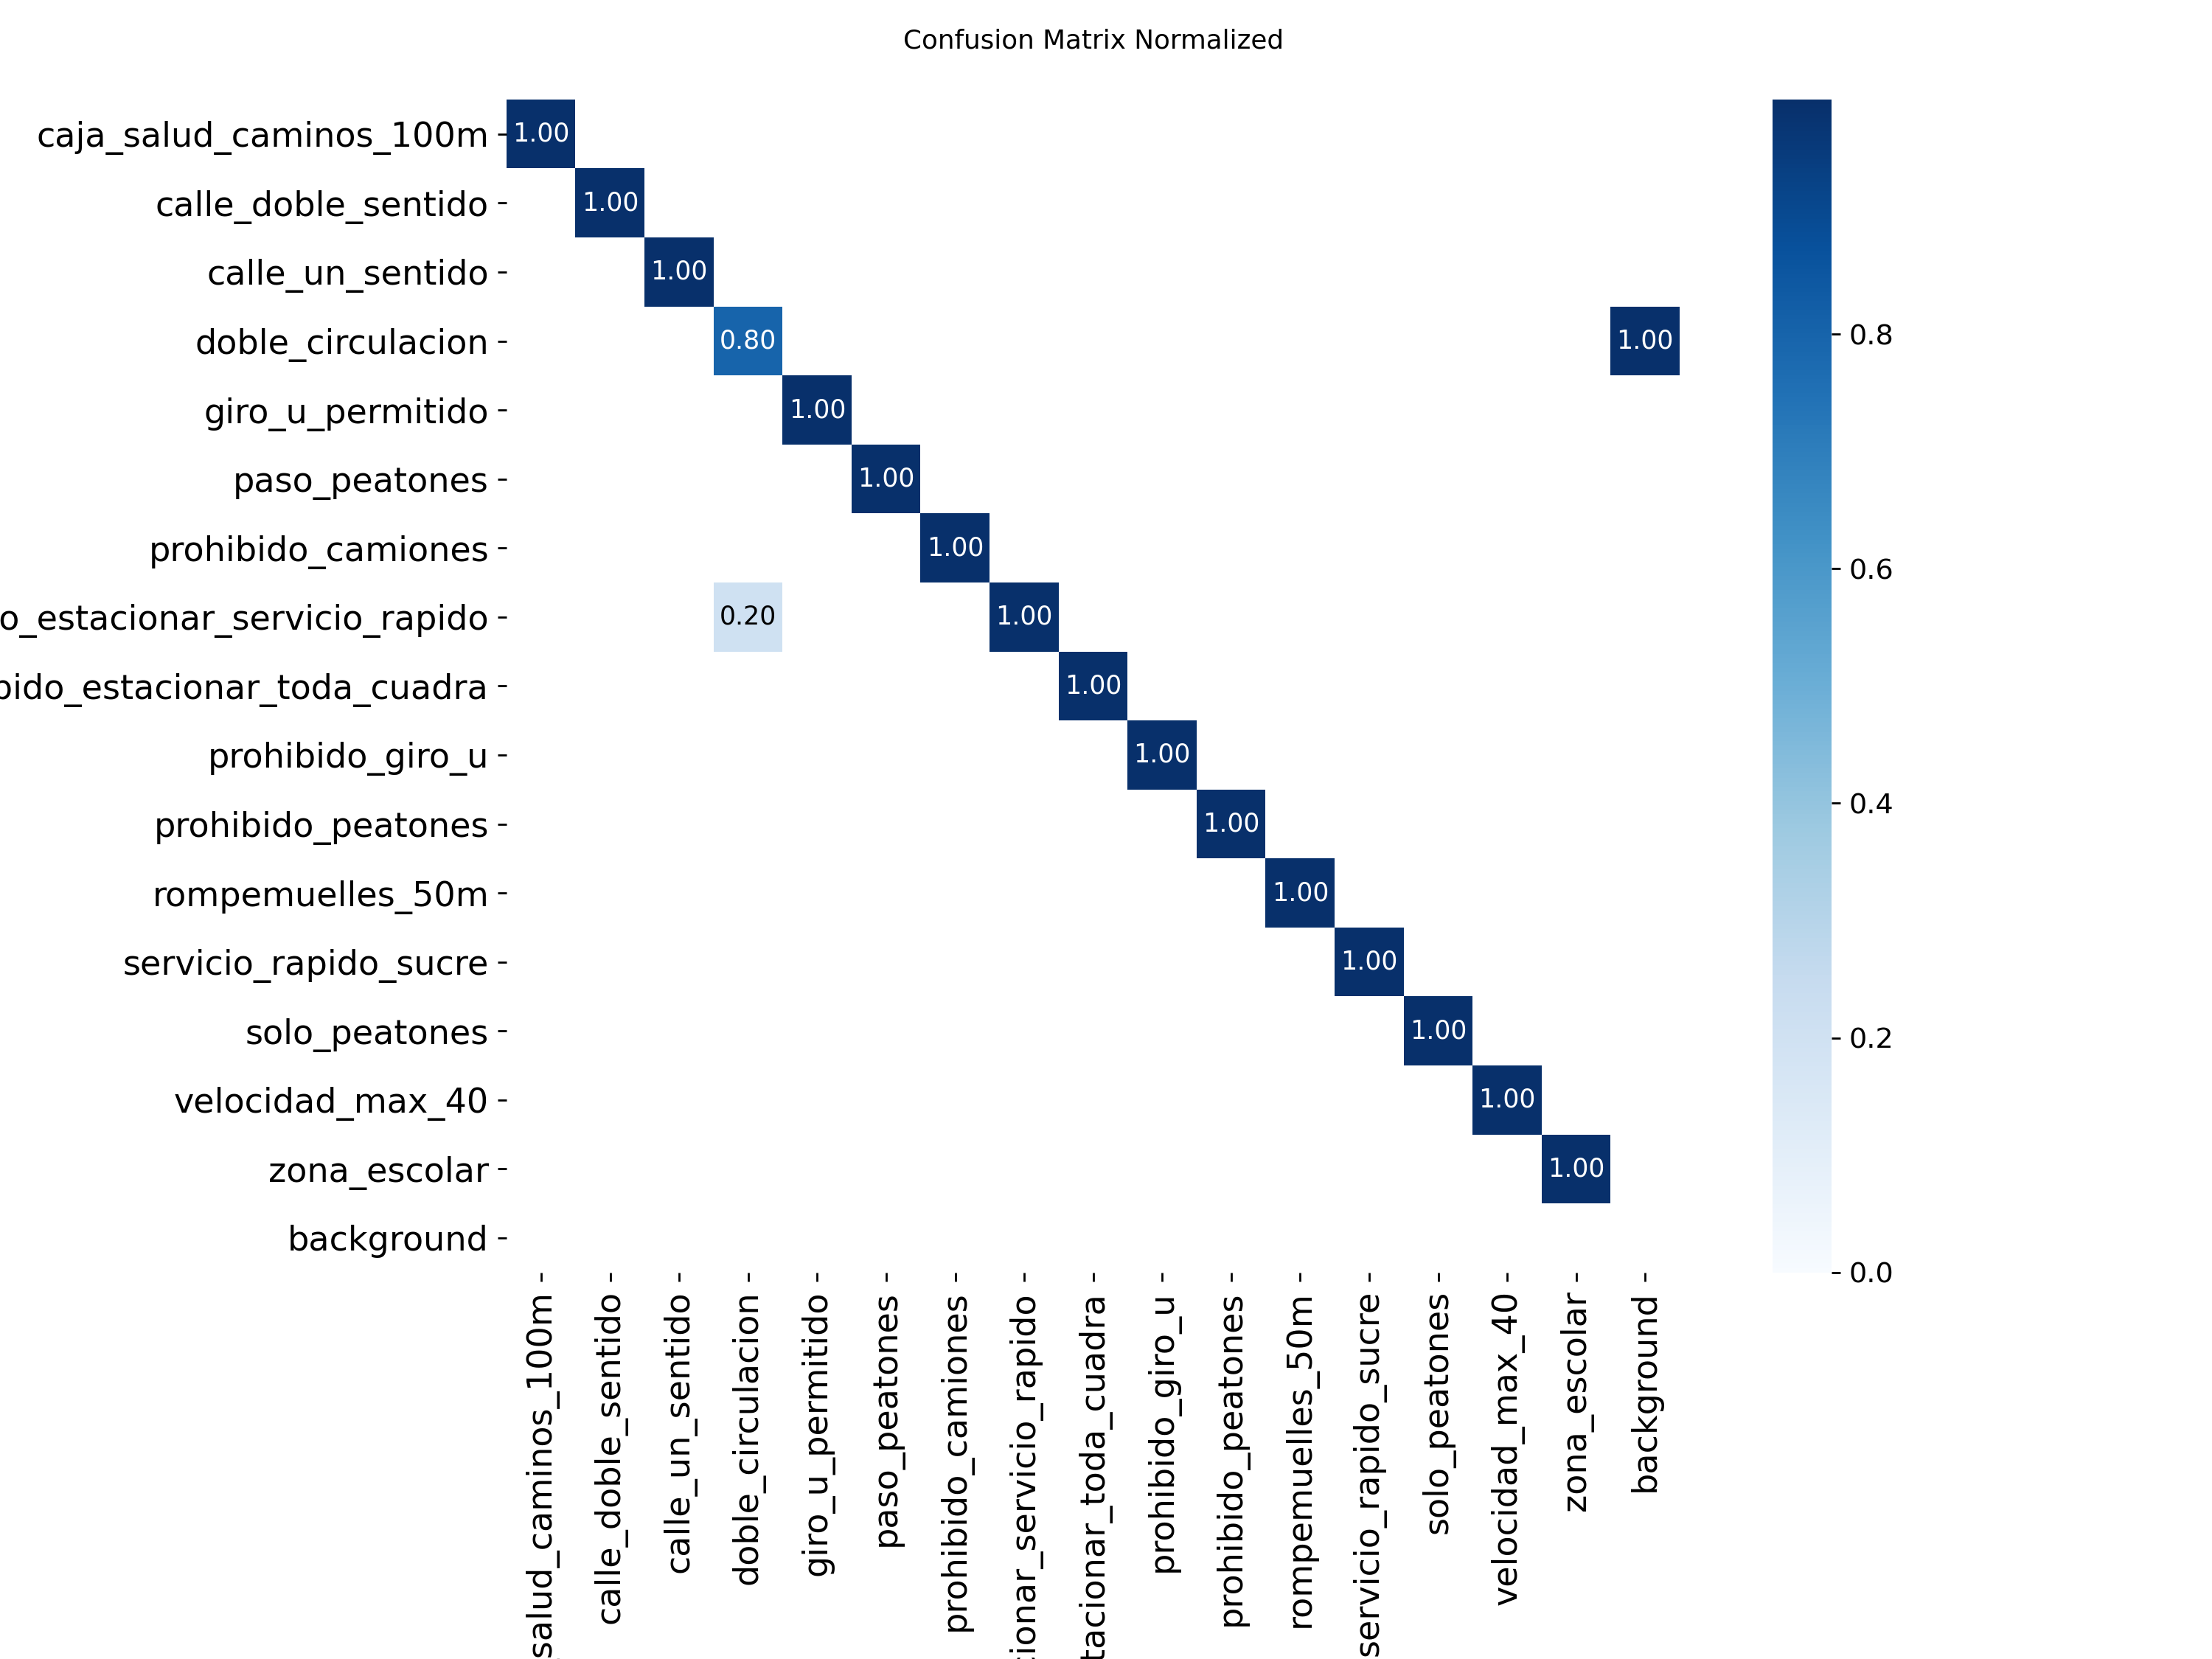


--- TABLERO DE RESULTADOS DE MÉTRICAS ---


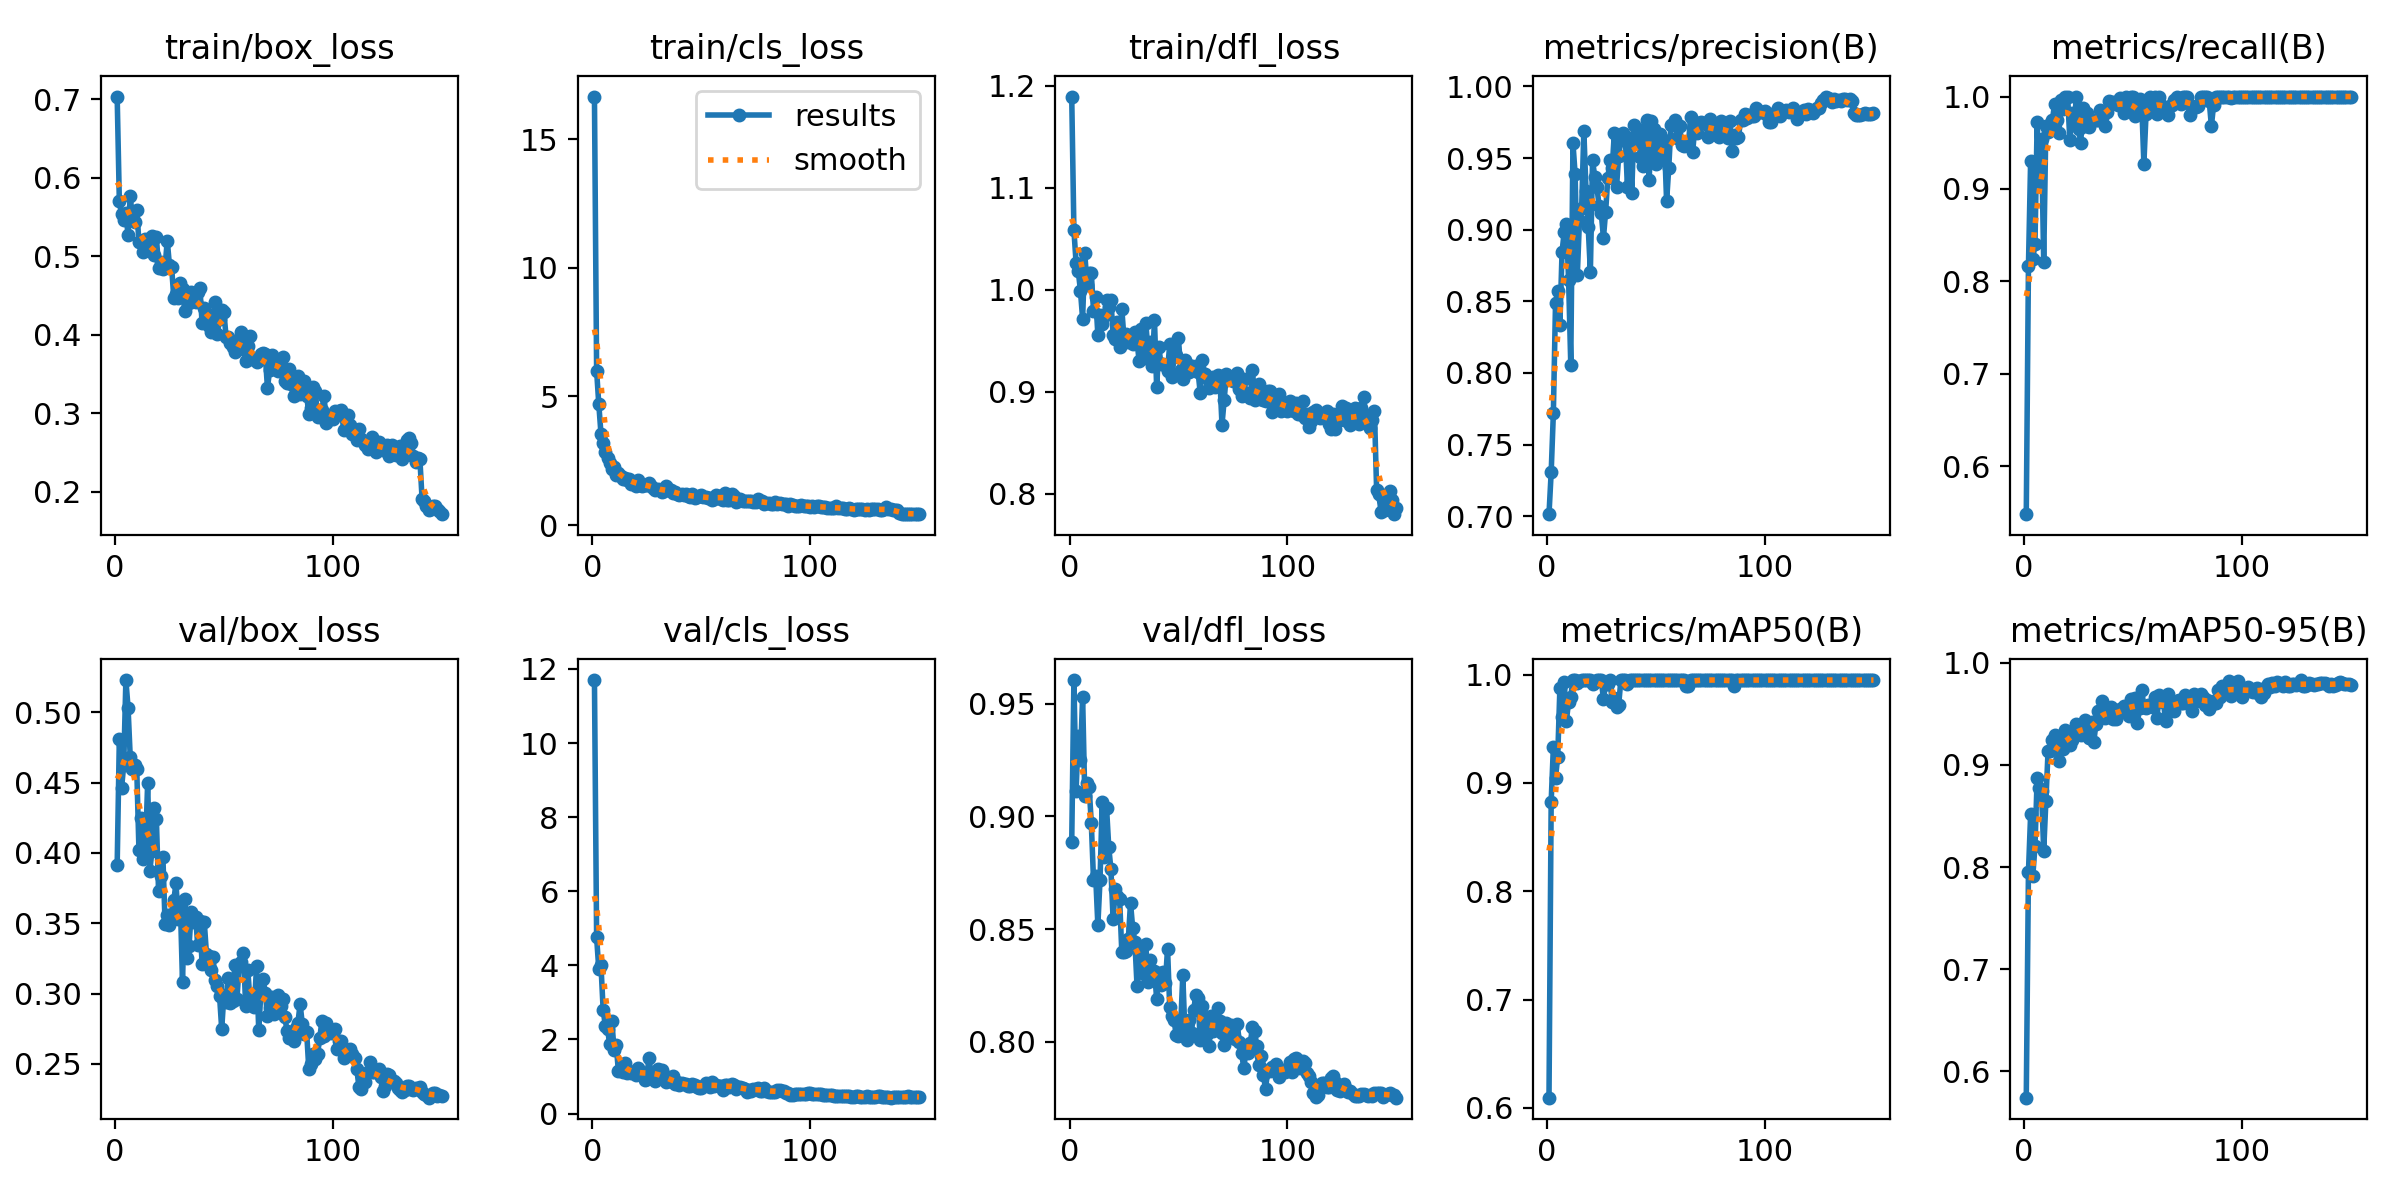

In [5]:
print("--- MATRIZ DE CONFUSIÓN NORMALIZADA ---")
display(Image(filename=str(latest_run / "confusion_matrix_normalized.png"), width=700))

print("\n--- TABLERO DE RESULTADOS DE MÉTRICAS ---")
display(Image(filename=str(latest_run / "results.png"), width=900))

## 5. Métricas de Rendimiento Detalladas por Clase

Cargaremos los pesos óptimos (`models/best.pt`) y ejecutaremos el proceso de validación sobre el conjunto de test/val para obtener e imprimir la precisión, recall y mAP individuales de cada clase.

In [6]:
# Cargar modelo óptimo
model_path = Path(settings.MODELS_DIR) / "best.pt"
model = YOLO(str(model_path))

print("[INFO] Ejecutando validación para extraer métricas por clase...")
# Correr validación
val_metrics = model.val(data=str(Path(settings.DATASET_DIR) / "data.yaml"), verbose=False)

# Obtener métricas por clase (usando atributos correctos de Metric de YOLOv8)
class_indices = val_metrics.box.ap_class_index
precisions = val_metrics.box.p
recalls = val_metrics.box.r
maps50 = val_metrics.box.ap50
maps95 = val_metrics.box.ap

class_performance = []
for idx, cls_idx in enumerate(class_indices):
    cls_name = settings.CLASS_NAMES.get(cls_idx, f"Clase {cls_idx}")
    class_performance.append({
        "Clase ID": cls_idx,
        "Nombre de la Señal": cls_name,
        "Precisión": f"{precisions[idx]*100:.2f}%",
        "Exhaustividad (Recall)": f"{recalls[idx]*100:.2f}%",
        "mAP@50": f"{maps50[idx]*100:.2f}%",
        "mAP@50:95": f"{maps95[idx]*100:.2f}%"
    })

# Convertir a DataFrame y dar formato visual
df_perf = pd.DataFrame(class_performance).sort_values("Clase ID")

# Mostrar la tabla de rendimiento por clase
display(df_perf.style.hide(axis="index").set_properties(**{
    'background-color': '#f9f9f9',
    'color': 'black',
    'border-color': 'lightgrey'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white'), ('font-weight', 'bold')]}
]))

[INFO] Ejecutando validación para extraer métricas por clase...
Ultralytics 8.4.54  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)


Model summary (fused): 73 layers, 11,131,776 parameters, 0 gradients, 28.5 GFLOPs


val: Fast image access  (ping: 0.10.0 ms, read: 982.9273.6 MB/s, size: 4039.3 KB)


val: Scanning C:\Users\franz\Desktop\ProyectoTecnoII\dataset\dataset_bolivia\val\labels.cache... 52 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 52/52  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 25% ━━━───────── 1/4 22.9s/it 6.9s<1:09

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.3s/it 9.2s

                   all         52         52      0.991          1      0.995       0.98


Speed: 5.5ms preprocess, 30.3ms inference, 0.1ms loss, 8.9ms postprocess per image


Results saved to C:\Users\franz\Desktop\ProyectoTecnoII\runs\detect\val-2


Clase ID,Nombre de la Señal,Precisión,Exhaustividad (Recall),mAP@50,mAP@50:95
0,Caja de Salud de Caminos a 100 metros,100.00%,100.00%,99.50%,99.50%
1,Calle de doble sentido,97.89%,100.00%,99.50%,99.50%
2,Calle de un solo sentido,99.12%,100.00%,99.50%,97.33%
3,Doble circulación,100.00%,100.00%,99.50%,99.50%
4,Giro en U permitido,97.28%,100.00%,99.50%,99.50%
5,Paso de peatones,99.30%,100.00%,99.50%,97.90%
6,Prohibido camiones,100.00%,100.00%,99.50%,99.50%
7,"Prohibido estacionar, servicio rápido",96.75%,100.00%,99.50%,99.50%
8,Prohibido estacionar en toda la cuadra,100.00%,100.00%,99.50%,99.50%
9,Prohibido giro en U,100.00%,100.00%,99.50%,99.50%


## 6. Resumen de Métricas Generales del Modelo

Imprimiremos el resumen final de las métricas agregadas del modelo.

In [7]:
print("=" * 60)
print("           RESUMEN GENERAL DE RENDIMIENTO DEL MODELO")
print("=" * 60)
print(f"Precisión Media (mAP@50) Global:   {val_metrics.box.map50*100:.2f}%")
print(f"mAP@50:95 Global:                  {val_metrics.box.map*100:.2f}%")
print(f"Precisión Promedio (Precision):    {val_metrics.box.mp*100:.2f}%")
print(f"Exhaustividad Promedio (Recall):   {val_metrics.box.mr*100:.2f}%")
print("=" * 60)

           RESUMEN GENERAL DE RENDIMIENTO DEL MODELO
Precisión Media (mAP@50) Global:   99.50%
mAP@50:95 Global:                  97.99%
Precisión Promedio (Precision):    99.06%
Exhaustividad Promedio (Recall):   100.00%
